---
## Step 1 — Import Libraries
First we import all the tools we need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load the Dataset
We load the CSV file using Pandas and take a first look at the data.

In [4]:
# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
# Show first 5 rows
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Check the shape — how many rows and columns
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')

Dataset has 9994 rows and 21 columns


In [6]:
# See all column names
print('Column names:')
print(df.columns.tolist())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## Step 3 — Data Cleaning
We check for missing values, fix data types, and remove duplicates.

In [7]:
# Check for missing values in each column
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Check data types of each column
print('Data types:')
print(df.dtypes)

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [9]:
# Fix data types — convert Order Date and Ship Date from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Month and Year from Order Date — we will use this later for trend analysis
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Month-Year'] = df['Order Date'].dt.to_period('M')

print('Date columns fixed successfully!')
print(df[['Order Date', 'Order Month', 'Order Year', 'Month-Year']].head())

Date columns fixed successfully!
  Order Date  Order Month  Order Year Month-Year
0 2016-11-08           11        2016    2016-11
1 2016-11-08           11        2016    2016-11
2 2016-06-12            6        2016    2016-06
3 2015-10-11           10        2015    2015-10
4 2015-10-11           10        2015    2015-10


In [10]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# Remove duplicates if any
df = df.drop_duplicates()
print(f'Dataset shape after removing duplicates: {df.shape}')

Number of duplicate rows: 0
Dataset shape after removing duplicates: (9994, 24)


In [11]:
# Basic statistics — get a summary of numeric columns
print('Basic statistics of numeric columns:')
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

Basic statistics of numeric columns:


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


---
## Step 4 — Analysis & Visualizations

### Question 1: Which Category has the Highest Sales?

In [ ]:
# Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
category_sales.columns = ['Category', 'Total Sales']
category_sales['Total Sales'] = category_sales['Total Sales'].round(2)

print('Total Sales by Category:')
print(category_sales)

# Bar Chart
plt.figure(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = plt.bar(category_sales['Category'], category_sales['Total Sales'], color=colors, edgecolor='white', width=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total Sales by Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Technology has the highest total sales!')

### Question 2: Which Region is Most Profitable?

Total Profit by Region:
    Region  Total Profit
0     West     108418.45
1     East      91522.78
2    South      46749.43
3  Central      39706.36


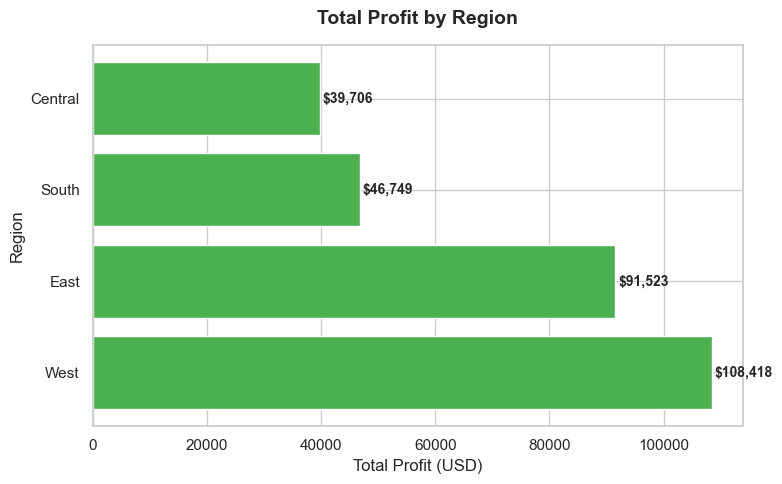


Insight: West region is the most profitable!


In [12]:
# Total Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()
region_profit.columns = ['Region', 'Total Profit']
region_profit['Total Profit'] = region_profit['Total Profit'].round(2)

print('Total Profit by Region:')
print(region_profit)

# Horizontal Bar Chart
plt.figure(figsize=(8, 5))
colors_region = ['#4CAF50' if x > 0 else '#F44336' for x in region_profit['Total Profit']]
bars = plt.barh(region_profit['Region'], region_profit['Total Profit'], color=colors_region, edgecolor='white')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2.,
             f'${width:,.0f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Total Profit by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Profit (USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: West region is the most profitable!')

### Question 3: What is the Monthly Sales Trend?

In [1]:
# Monthly Sales Trend (all years combined by month)
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total Sales']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales['Month Name'] = monthly_sales['Month'].apply(lambda x: month_names[x-1])

# Line Chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month Name'], monthly_sales['Total Sales'],
         marker='o', color='#2196F3', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)

# Fill area under line
plt.fill_between(monthly_sales['Month Name'], monthly_sales['Total Sales'],
                 alpha=0.1, color='#2196F3')

# Add value labels on each point
for i, row in monthly_sales.iterrows():
    plt.text(i, row['Total Sales'] + 5000, f"${row['Total Sales']:,.0f}",
             ha='center', va='bottom', fontsize=8)

plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Sales peak in November and December (holiday season)!')

NameError: name 'df' is not defined

### Visualization 4: Profit vs Sales by Sub-Category (Heatmap)

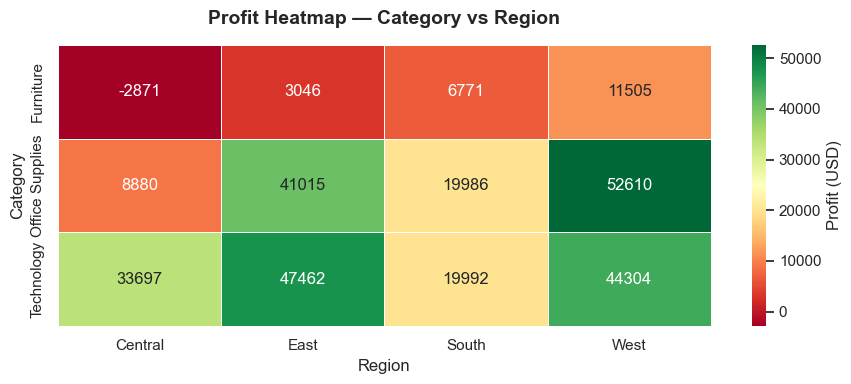


Insight: Technology in the West region is the most profitable combination!
Insight: Furniture in Central region is making a loss (shown in red)!


In [14]:
# Heatmap — Sales and Profit by Category and Region
pivot_table = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum').round(0)

plt.figure(figsize=(9, 4))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Profit (USD)'})

plt.title('Profit Heatmap — Category vs Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_profit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Technology in the West region is the most profitable combination!')
print('Insight: Furniture in Central region is making a loss (shown in red)!')

### Visualization 5: Top 10 Sub-Categories by Sales

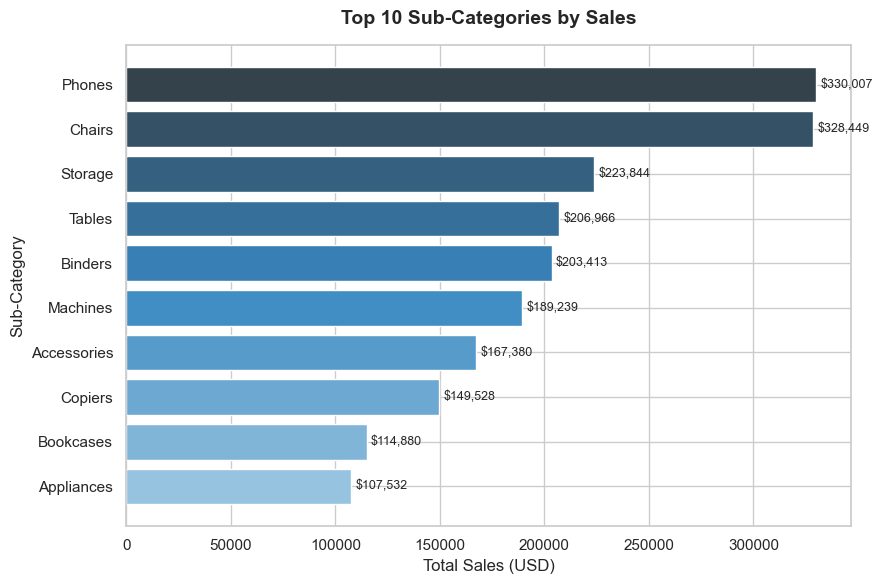


Insight: Phones and Chairs are the top selling sub-categories!


In [15]:
# Top 10 Sub-Categories by Sales
sub_cat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 6))
colors_sub = sns.color_palette('Blues_d', len(sub_cat_sales))
bars = plt.barh(sub_cat_sales.index, sub_cat_sales.values, color=colors_sub)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2000, bar.get_y() + bar.get_height()/2.,
             f'${width:,.0f}', ha='left', va='center', fontsize=9)

plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales (USD)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_top_subcategories.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Phones and Chairs are the top selling sub-categories!')

---
## Step 5 — Key Findings Summary

In [16]:
print('=' * 55)
print('       KEY FINDINGS FROM SUPERSTORE ANALYSIS')
print('=' * 55)

top_category = df.groupby('Category')['Sales'].sum().idxmax()
top_region = df.groupby('Region')['Profit'].sum().idxmax()
top_subcategory = df.groupby('Sub-Category')['Sales'].sum().idxmax()
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f'\n Total Records Analyzed : {len(df):,}')
print(f' Total Revenue          : ${total_sales:,.2f}')
print(f' Total Profit           : ${total_profit:,.2f}')
print(f' Overall Profit Margin  : {profit_margin:.1f}%')
print(f'\n Top Category by Sales  : {top_category}')
print(f' Most Profitable Region : {top_region}')
print(f' Top Sub-Category       : {top_subcategory}')
print(f'\n Sales peak in Nov-Dec (holiday season)')
print(f' Furniture in Central region incurs losses')
print(f' Technology drives highest revenue overall')
print('=' * 55)

       KEY FINDINGS FROM SUPERSTORE ANALYSIS

 Total Records Analyzed : 9,994
 Total Revenue          : $2,297,200.86
 Total Profit           : $286,397.02
 Overall Profit Margin  : 12.5%

 Top Category by Sales  : Technology
 Most Profitable Region : West
 Top Sub-Category       : Phones

 Sales peak in Nov-Dec (holiday season)
 Furniture in Central region incurs losses
 Technology drives highest revenue overall


---
## Conclusion

This EDA revealed several important business insights from the Superstore dataset:

1. **Technology** is the highest revenue-generating category.
2. **West region** is the most profitable region overall.
3. **Sales peak in Q4** (November & December), suggesting strong seasonal demand.
4. **Furniture in the Central region** is operating at a loss — the business should review discounting strategy there.
5. **Phones and Chairs** are the top-selling sub-categories.


